In [11]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
print(os.getcwd())

C:\Users\Lenovo\Documents\SCUOLA\UNI\MASTER\2ANNO\HANDS ON GENERATIVE AI


In [3]:
# 1. Define the Transform (Critical for Diffusion)
# We crop to square (178x178) then resize to a power of 2 (e.g., 128x128)
image_size = 178
transform = transforms.Compose([
    transforms.CenterCrop(178),         # Crop the center square
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize to [-1, 1] for Diffusion
])

In [4]:
image_folder = './data/celeba/img_align_celeba'
# Check if folder exists
if os.path.exists(image_folder):
    num_files = len([name for name in os.listdir(image_folder) if name.endswith('.jpg')])
    print(f"Actual images found on disk: {num_files}")
    print(f"Images expected by PyTorch: 202,599")
else:
    print(f"Folder not found: {image_folder}")

Actual images found on disk: 202599
Images expected by PyTorch: 202,599


In [5]:
# --- CONFIGURATION ---
# NOTE: 178 is the native crop, but for U-Nets (Diffusion), 
# you usually need powers of 2 (e.g., 64, 128, 256) to handle downsampling.
# I recommend changing this to 128 or 256.
IMAGE_SIZE = 128
BATCH_SIZE = 64
DATA_PATH = './data' # Pointing to the folder containing 'celeba'

# --- 1. DEFINE TRANSFORM ---
transform = transforms.Compose([
    transforms.CenterCrop(178),                 # Crop the square face
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), # Resize to power of 2
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # [-1, 1] range
])

# --- 2. DEFINE ROBUST DATASET CLASS ---
# This class bypasses the MD5 checksum verification which often fails on Windows/Kaggle downloads
class CelebA_Relaxed(datasets.CelebA):
    def _check_integrity(self) -> bool:
        return True

# --- 3. LOAD DATASET ---
try:
    dataset = CelebA_Relaxed(root=DATA_PATH, 
                             split='train', 
                             target_type='attr', 
                             transform=transform, 
                             download=False)
    
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    print(f"Dataset loaded. Total images: {len(dataset)}")
    print(f"Loader: {loader}")

except Exception as e:
    print(f"Error loading dataset: {e}")

Dataset loaded. Total images: 162770
Loader: <torch.utils.data.dataloader.DataLoader object at 0x000001E8DA47C500>


In [6]:
# --- 4. VISUALIZE BATCH ---
# Get one batch
real_batch = next(iter(loader))
images, labels = real_batch

# Print Tensor Shape
print(f"Tensor Shape: {images.shape}") 
# Expected: torch.Size([BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE])

Tensor Shape: torch.Size([64, 3, 128, 128])


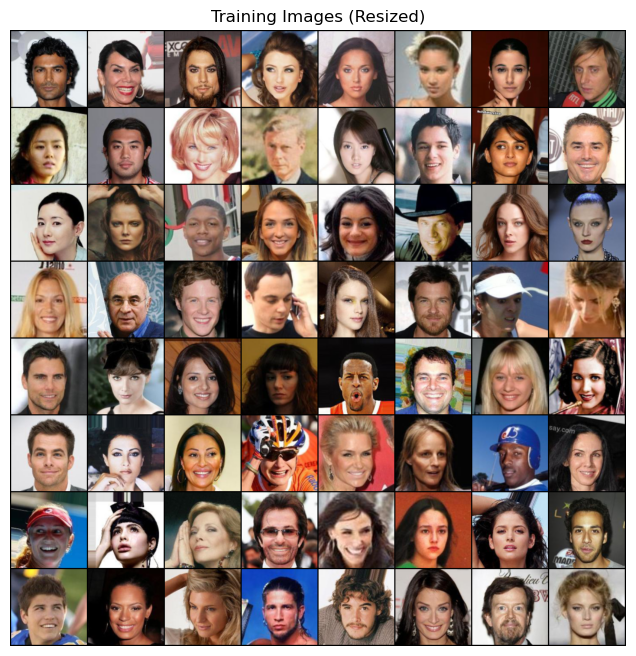

In [12]:
# Plot
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images (Resized)")

# We have to 'denormalize' from [-1, 1] back to [0, 1] for matplotlib
grid = vutils.make_grid(images[:64], padding=2, normalize=True)
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.show()

# Resize
Reshape it as a multiple of two.

Tensor Shape: torch.Size([64, 3, 128, 128])


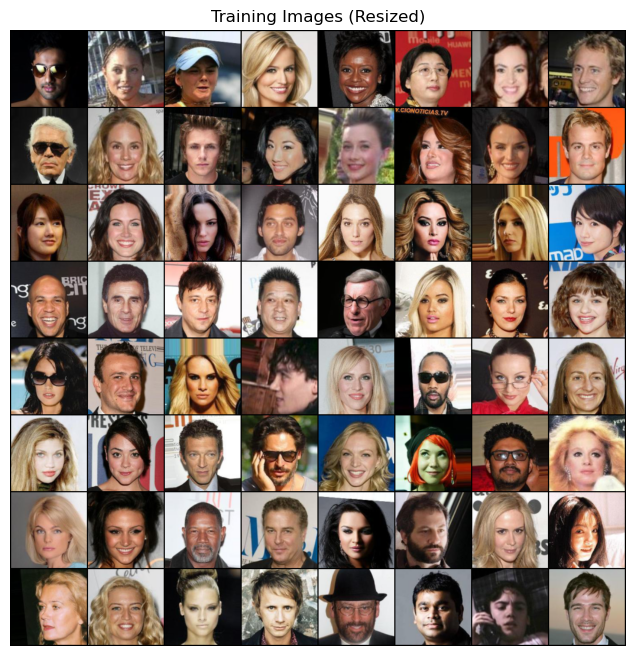

In [13]:
# I recommend changing this to 128 or 256.
IMAGE_SIZE = 178
BATCH_SIZE = 32
DATA_PATH = './data' # Pointing to the folder containing 'celeba'

# --- 1. DEFINE TRANSFORM ---
transform = transforms.Compose([
    transforms.CenterCrop(178),                 # Crop the square face
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), # Resize to power of 2
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # [-1, 1] range
])
# --- 4. VISUALIZE BATCH ---
# Get one batch
real_batch = next(iter(loader))
images, labels = real_batch

# Print Tensor Shape
print(f"Tensor Shape: {images.shape}") 
# Expected: torch.Size([32, 3, 128, 128])

# Plot
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images (Resized)")

# We have to 'denormalize' from [-1, 1] back to [0, 1] for matplotlib
grid = vutils.make_grid(images[:64], padding=2, normalize=True)
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.show()